# Semana 2 · Experimento del estudiante: tokens, atención y decoding

Este notebook acompaña la sesión. En cada sección hay una **predicción** que se escribe antes de ejecutar y un **TODO** para experimentar. Corre completo en Colab con CPU.

Reglas:

1. Escribir la predicción antes de correr la celda que la verifica.
2. Al final, responder las preguntas de cierre en la celda de texto.

Entregable: este notebook ejecutado, con predicciones, resultados y respuestas.

In [1]:
# Instalación (en Colab tarda un minuto; si las librerías ya están instaladas no hace nada)
import subprocess, sys
_ = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "torch", "matplotlib"],
                   capture_output=True)

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True)

tok = AutoTokenizer.from_pretrained("gpt2")
# attn_implementation="eager" es necesario para obtener los pesos de atención con output_attentions=True
model = AutoModelForCausalLM.from_pretrained("gpt2", dtype=torch.float32, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"vocabulary:        {cfg.vocab_size:,} tokens")
print(f"context window:    {cfg.n_positions:,} posiciones")
print(f"d_model:           {cfg.n_embd} (dimensión de cada vector)")
print(f"bloques:           {cfg.n_layer}   cabezas por bloque: {cfg.n_head}")
print(f"parámetros:        {sum(p.numel() for p in model.parameters())/1e6:.0f} M")

vocabulary:        50,257 tokens
context window:    1,024 posiciones
d_model:           768 (dimensión de cada vector)
bloques:           12   cabezas por bloque: 12
parámetros:        124 M


In [4]:
def limpiar(t):
    """Los tokens de GPT-2 marcan el espacio previo con 'Ġ'. Se cambia por '␣' para leerlos."""
    return t.replace("Ġ", "␣").replace("Ċ", "\\n")

def mostrar_tokens(texto):
    ids = tok(texto).input_ids
    toks = [limpiar(t) for t in tok.convert_ids_to_tokens(ids)]
    print(f"{texto!r}")
    print(f"  palabras: {len(texto.split())}   tokens: {len(ids)}   tokens/palabra: {len(ids)/len(texto.split()):.2f}")
    print(f"  tokens:   {toks}")
    print(f"  ids:      {ids}")
    return ids

## 1. Tokens

**Predicción 1.** ¿Cuántos tokens tiene la frase de abajo en GPT-2? Escribe tu número en `MI_PREDICCION` antes de ejecutar.

In [5]:
frase = "Arquitectura de software para sistemas inteligentes"
MI_PREDICCION = 15   # TODO: escribe un entero antes de ejecutar

ids = mostrar_tokens(frase)
print(f"\npredicción: {MI_PREDICCION}   real: {len(ids)}")

'Arquitectura de software para sistemas inteligentes'
  palabras: 6   tokens: 14   tokens/palabra: 2.33
  tokens:   ['Ar', 'qu', 'itect', 'ura', '␣de', '␣software', '␣para', '␣s', 'ist', 'em', 'as', '␣intel', 'igent', 'es']
  ids:      [3163, 421, 5712, 5330, 390, 3788, 31215, 264, 396, 368, 292, 33649, 47096, 274]

predicción: 15   real: 14


In [21]:
# TODO: escribe una frase tuya en español y la misma idea en inglés. Compara tokens por palabra.
mi_es = "Me cobraron dos veces la mensualidad de julio. Necesito el reembolso del cargo duplicado."
mi_en = "TODO: I am learning how to use this project"
_ = mostrar_tokens(mi_es)
_ = mostrar_tokens(mi_en)

'Me cobraron dos veces la mensualidad de julio. Necesito el reembolso del cargo duplicado.'
  palabras: 14   tokens: 30   tokens/palabra: 2.14
  tokens:   ['Me', '␣cob', 'r', 'aron', '␣dos', '␣ve', 'ces', '␣la', '␣m', 'ensual', 'idad', '␣de', '␣j', 'ul', 'io', '.', '␣Nec', 'es', 'ito', '␣el', '␣re', 'emb', 'ol', 'so', '␣del', '␣cargo', '␣dupl', 'ic', 'ado', '.']
  ids:      [5308, 22843, 81, 8045, 23430, 1569, 728, 8591, 285, 31406, 32482, 390, 474, 377, 952, 13, 19652, 274, 10094, 1288, 302, 24419, 349, 568, 1619, 15892, 14184, 291, 4533, 13]
'TODO: I am learning how to use this project'
  palabras: 9   tokens: 12   tokens/palabra: 1.33
  tokens:   ['T', 'OD', 'O', ':', '␣I', '␣am', '␣learning', '␣how', '␣to', '␣use', '␣this', '␣project']
  ids:      [51, 3727, 46, 25, 314, 716, 4673, 703, 284, 779, 428, 1628]


**Pregunta 1.** ¿Por qué el español necesita más tokens que el inglés con este tokenizer? ¿Qué consecuencia tiene para el costo y la ventana de contexto de una aplicación en español?

_Respuesta:_ Por que el modelo esta entrenado en inglés, así que palabras comunes del inglés ocupan hasta un solo token, mientras que en el español estas se fragmentan.

En la mayoría por no decir todos los agentes cobran por token, de salida como de entrada al generarse más tokens es más costo. Y en tanto al contexto al generarse más tokens tienen que recordar más cosas, tal vez esto no se ve muy claro porque solo es un texto pequeño pero en documentos largos es más notable

## 2. Embeddings

Cada token ID selecciona una fila de una matriz aprendida. Tokens que aparecen en contextos parecidos quedan con vectores parecidos.

In [7]:
wte = model.transformer.wte.weight
print("matriz de embeddings:", tuple(wte.shape))

def similitud(a, b):
    va, vb = wte[tok(a).input_ids[0]], wte[tok(b).input_ids[0]]
    return torch.cosine_similarity(va, vb, dim=0).item()

# TODO: ordena estos pares de mayor a menor similitud ANTES de ejecutar, en MI_ORDEN (lista de índices 0..3).
pares = [(" cat", " dog"), (" cat", " car"), (" king", " queen"), (" king", " banana")]
MI_ORDEN = [0,2,1,3]   # por ejemplo [0, 2, 1, 3]

for i, (a, b) in enumerate(pares):
    print(f"{i}: {a!r:8} vs {b!r:9} -> {similitud(a, b):.3f}")
print("mi orden:", MI_ORDEN)

matriz de embeddings: (50257, 768)
0: ' cat'   vs ' dog'    -> 0.550
1: ' cat'   vs ' car'    -> 0.381
2: ' king'  vs ' queen'  -> 0.657
3: ' king'  vs ' banana' -> 0.256
mi orden: [0, 2, 1, 3]


## 3. Self-attention

### 3.1 A mano

La celda de abajo reproduce el ejercicio en papel. Antes de ejecutarla, calcula a mano la fila de 'gato' (pesos con máscara causal) y escríbela en `MI_FILA_GATO`.

In [9]:
MI_FILA_GATO = [0.67,0.33,0]   # TODO: por ejemplo [0.5, 0.5, 0.0]

# Tres tokens con embeddings de dimensión 2. En GPT-2 la dimensión es 768 y las matrices W se aprenden.
tokens = ["el", "gato", "duerme"]
X = np.array([[1.0, 0.0],
              [0.0, 1.0],
              [1.0, 1.0]])
W_Q = np.array([[1.0, 0.0], [0.0, 1.0]])
W_K = np.array([[1.0, 0.0], [0.0, 1.0]])   # intercambia coordenadas: la key de un token difiere de su query
W_V = np.array([[1.0, 0.0], [0.0, 1.0]])

Q, K, V = X @ W_Q, X @ W_K, X @ W_V
d_k = Q.shape[1]
scores = Q @ K.T / np.sqrt(d_k)
mask = np.triu(np.ones_like(scores, dtype=bool), k=1)       # True donde j > i (futuro)
scores_masked = np.where(mask, -np.inf, scores)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

A = softmax(scores_masked)
salida = A @ V
print("scores / sqrt(d_k):\n", scores)
print("\ncon máscara causal:\n", scores_masked)
print("\npesos de atención:\n", A)
print("\nsalida = A @ V:\n", salida)
for i, t in enumerate(tokens):
    print(f"  '{t}' mira a: " + ", ".join(f"{tokens[j]}={A[i, j]:.2f}" for j in range(i + 1)))
print("\nmi fila de 'gato':", MI_FILA_GATO, "  real:", A[1])

scores / sqrt(d_k):
 [[0.707 0.    0.707]
 [0.    0.707 0.707]
 [0.707 0.707 1.414]]

con máscara causal:
 [[0.707  -inf  -inf]
 [0.    0.707  -inf]
 [0.707 0.707 1.414]]

pesos de atención:
 [[1.    0.    0.   ]
 [0.33  0.67  0.   ]
 [0.248 0.248 0.503]]

salida = A @ V:
 [[1.    0.   ]
 [0.33  0.67 ]
 [0.752 0.752]]
  'el' mira a: el=1.00
  'gato' mira a: el=0.33, gato=0.67
  'duerme' mira a: el=0.25, gato=0.25, duerme=0.50

mi fila de 'gato': [0.67, 0.33, 0]   real: [0.33 0.67 0.  ]


**Pregunta 2.** Cambia `W_K` por la identidad (igual que `W_Q`) y vuelve a ejecutar. ¿Qué cambia en la fila de 'gato' y por qué?

_Respuesta:_ Los pesos se invierten, la fila gato pasa de [0.67, 0.33] a [0.33, 0.67]. Esto cambio porque la atención cambio, ya que mide que tan parecida es la query de un token a la key, y al cambiar la key altero el resultado

### 3.2 Atención real en GPT-2

In [10]:
def mapa_atencion(texto, capa, cabeza, ax=None):
    ids = tok(texto, return_tensors="pt").input_ids
    labels = [limpiar(t) for t in tok.convert_ids_to_tokens(ids[0])]
    with torch.no_grad():
        out = model(ids, output_attentions=True)
    att = out.attentions[capa][0, cabeza].numpy()      # (tokens, tokens)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(att, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    ax.set_xlabel("Key (a quién se mira)"); ax.set_ylabel("Query (quién mira)")
    ax.set_title(f"capa {capa}, cabeza {cabeza}")
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, hatch="///", fill=False, edgecolor="gray", lw=0))
    return att, labels

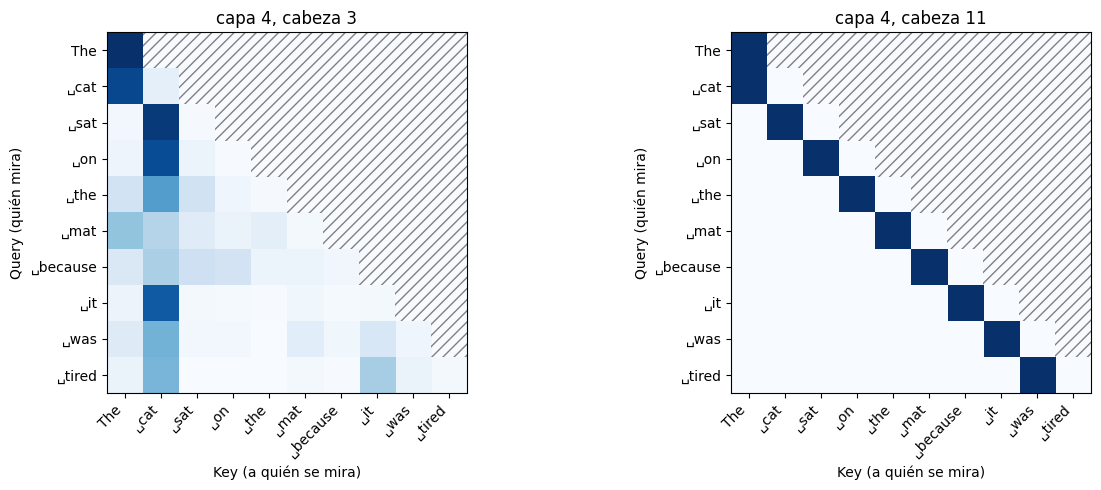

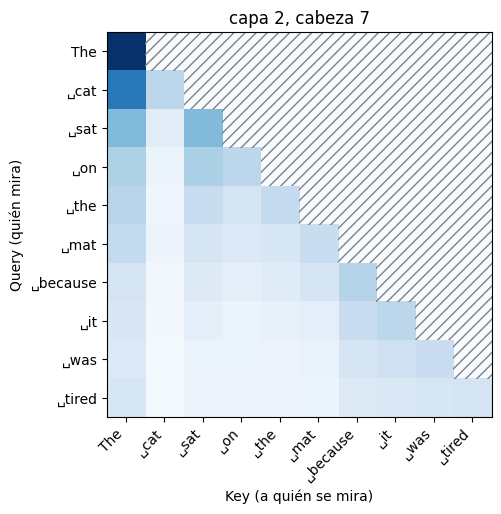

In [12]:
frase = "The cat sat on the mat because it was tired"
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
att3, labels = mapa_atencion(frase, capa=4, cabeza=3, ax=axes[0])
att11, _ = mapa_atencion(frase, capa=4, cabeza=11, ax=axes[1])
plt.tight_layout(); plt.show()

# TODO: explora otra capa y otra cabeza (0 a 11 cada una). ¿Encuentras alguna con un patrón que puedas describir?
MI_CAPA, MI_CABEZA = 2, 7
att_mia, _ = mapa_atencion(frase, capa=MI_CAPA, cabeza=MI_CABEZA)
plt.show()

**Pregunta 3.** ¿Por qué el triángulo superior de cada mapa está bloqueado? ¿Qué aprendería el modelo si no lo estuviera durante el entrenamiento?

_Respuesta:_ Porque el modelo solo puede mirar palabras anteriores, no las que vienen después, ese triangulo representa esas palabras que vienen después, son pesos imposibles y los pone como 0.
El modelo probablemente haría trampa ya que al tener la respuesta pues simplemente la copiaria en lugar de intentar aprender

## 4. Logits y decoding

**Predicción 2.** ¿Cuál es el token más probable después de `"The cat sat on the"`? Escríbelo en `MI_TOKEN`.

In [14]:
MI_TOKEN = " table"   # TODO: por ejemplo " floor"

ids = tok("The cat sat on the", return_tensors="pt").input_ids
with torch.no_grad():
    ultimo = model(ids).logits[0, -1]
probs = torch.softmax(ultimo, dim=-1)
top = torch.topk(probs, 10)
for p, i in zip(top.values, top.indices):
    print(f"  {tok.decode([i])!r:12} prob={p:.3f}")
print("\nmi predicción:", MI_TOKEN)

  ' floor'     prob=0.076
  ' bed'       prob=0.065
  ' couch'     prob=0.054
  ' ground'    prob=0.052
  ' edge'      prob=0.048
  ' bench'     prob=0.032
  ' table'     prob=0.032
  ' sofa'      prob=0.029
  ' other'     prob=0.020
  ' back'      prob=0.019

mi predicción:  table


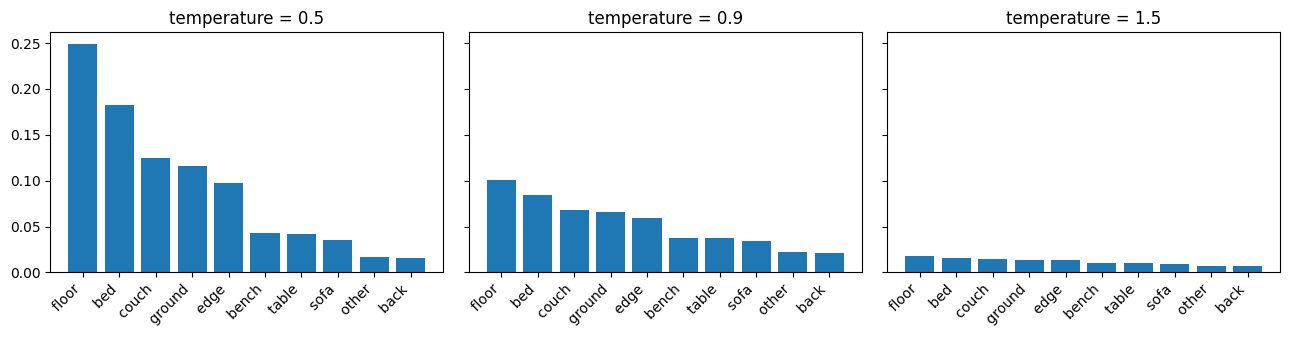

In [16]:
# La misma distribución a distintas temperaturas. TODO: cambia los tres valores de T y observa.
MIS_TEMPERATURAS = [0.5, 0.9, 1.5]
cand = top.indices
fig, axes = plt.subplots(1, len(MIS_TEMPERATURAS), figsize=(13, 3.5), sharey=True)
for ax, T in zip(axes, MIS_TEMPERATURAS):
    p = torch.softmax(ultimo / T, dim=-1)[cand].numpy()
    ax.bar(range(10), p)
    ax.set_xticks(range(10)); ax.set_xticklabels([limpiar(tok.decode([i])) for i in cand], rotation=45, ha="right")
    ax.set_title(f"temperature = {T}")
plt.tight_layout(); plt.show()

In [19]:
def generar(prefijo, n=3, max_new_tokens=15, **kw):
    ids = tok(prefijo, return_tensors="pt").input_ids
    return [tok.decode(model.generate(ids, max_new_tokens=max_new_tokens, pad_token_id=tok.eos_token_id, **kw)[0, ids.shape[1]:]) for _ in range(n)]

prefijo = "The software architect opened the report and"

# TODO: completa la tabla. Para cada configuración, predice cuántas salidas DISTINTAS habrá en 3 corridas (1, 2 o 3).
configs = {
    "greedy":          (dict(do_sample=False),                 1),   # (configuración, mi predicción)
    "temperature=0.2": (dict(do_sample=True, temperature=0.3), 2),
    "temperature=1.5": (dict(do_sample=True, temperature=1.8), 3),
    "top-p=0.9":       (dict(do_sample=True, top_p=0.9, top_k=0), 3),
}
for nombre, (cfg, pred) in configs.items():
    salidas = generar(prefijo, **cfg)
    print(f"\n=== {nombre}: predije {pred}, distintas = {len(set(salidas))} ===")
    for x in salidas:
        print("  ", repr(x))


=== greedy: predije 1, distintas = 1 ===
   ' said that the company\'s "high-quality, high-quality, high'
   ' said that the company\'s "high-quality, high-quality, high'
   ' said that the company\'s "high-quality, high-quality, high'

=== temperature=0.2: predije 2, distintas = 3 ===
   ' said that the company was "very pleased" with the results.\n\n'
   ' said, "We are very pleased with the results of the study."\n'
   ' said that the company had been "very clear that we were not going to'

=== temperature=1.5: predije 3, distintas = 3 ===
   ' quickly realized: "I know not every aspect of any specific algorithm will have'
   ' called for "a fundamental and long-winded change for both the federal'
   ' found himself in a difficult legal context. Under EU/FAI directives ,'

=== top-p=0.9: predije 3, distintas = 3 ===
   ' said, "Google\'s first demo video was the Superbowl, in the'
   " said it's actually quite useful for solving problem cases. It used to be"
   ' received a big app

**Pregunta 4.** Cuando subes la temperatura, ¿qué cambia en los logits? ¿Y en las probabilidades? Explica en dos líneas.

_Respuesta:_ Los logits siguen con el mismo valor pero se dividen entre la temperatura antes del softmax. Con la temperatura alta las diferencias se "aplanan" y las probabilidades se reparten más parejo mientras que con la temperatura baja estan se muestran más y la opción más probable se nota más

**Pregunta 5.** Para clasificar tickets de soporte en cinco categorías, ¿qué estrategia de decoding usarías y por qué? ¿Y para proponer nombres de un producto?

_Respuesta:_ Usaría la temperatura muy baja porque la tarea ya tiene una respuesta en concreto y la creatividad solo me daría errores. Y para proponer nombres usaría una temperatura media ya que si quiero que sea más creativa pero no tanto para que no alucine

## 5. Ventana de contexto

In [20]:
# Predicción 3: ¿qué pasa si se envían 1,100 tokens a un modelo con ventana de 1,024?
MI_PREDICCION_VENTANA = "error"   # TODO: "error", "trunca", "funciona"

# Desbordamiento del context window: GPT-2 conoce 1,024 posiciones.
texto_largo = "token " * 1100
ids = tok(texto_largo, return_tensors="pt").input_ids
print("tokens de entrada:", ids.shape[1], "| ventana:", model.config.n_positions)
try:
    with torch.no_grad():
        model(ids)
    print("sin error (¿?)")
except Exception as e:
    print("ERROR:", type(e).__name__, "->", str(e)[:160], "...")
print("\nmi predicción:", MI_PREDICCION_VENTANA)

tokens de entrada: 1101 | ventana: 1024
ERROR: IndexError -> index out of range in self ...

mi predicción: error


## 6. Cierre

Responde en esta celda:

1. Explica con tus palabras por qué el modelo de la semana 1 dio respuestas distintas cada vez.
2. Explica por qué inventó una fecha sin "darse cuenta".
3. Para la mesa de soporte del curso: ¿cuántos tokens estimas que ocupa este ticket? "Me cobraron dos veces la mensualidad de julio. Necesito el reembolso del cargo duplicado." Escribe tu estimación, tokenízalo y anota el número real.

_Respuestas:_
1. Porque el modelo no calcula una respuesta fija, en cada paso calulaba las probabilidaes para el siguiente token.
2. Porque el modelo solo hace una cosa que es continuar el texto con lo que le suena más probable, no tiene una base de datos u acceso a internet
3. Estimación: Unos 35 tokens, ya que con lo visto en clase cuando es en español aumenta aprox unos 2.5 tokens, así que al ser 14 palabras por 2.5 nos da 35

Real: 30